In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

### W01A

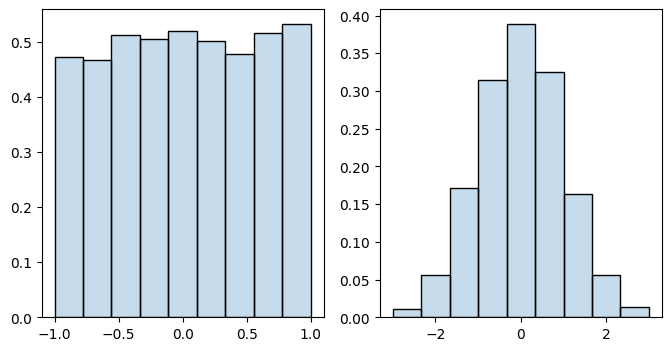

In [3]:
class Distribution():
    def __init__(self, xmin=0, xmax=1):
        self.xmin = xmin
        self.xmax = xmax
        self._set_xvals()

    def plot(self, ax):
        Nbins = 10
        xedges = np.linspace(self.xmin, self.xmax, Nbins)
        xcenters = (xedges[:-1] + xedges[1:]) / 2
        xwidth = xedges[1] - xedges[0]
        assert xwidth > 0
        bars, _ = np.histogram(self.xvals, xedges)
        P = bars / np.sum(bars) / xwidth
        ax.bar(xcenters, P, width=xwidth, facecolor='C0', alpha=0.25)
        ax.bar(xcenters, P, width=xwidth, facecolor='None', edgecolor='k')

class Uniform(Distribution):
    def _set_xvals(self):
        self.xvals = np.random.rand(10000) * (self.xmax-self.xmin) + self.xmin

class Normal(Distribution):
    def _set_xvals(self):
        self.xvals = np.random.randn(10000)

fig, axes = plt.subplots(1,2, figsize=(8,4))

uniform = Uniform(-1, 1)
normal = Normal(-3, 3)

for object, ax in zip((uniform, normal), axes):
    object.plot(ax)

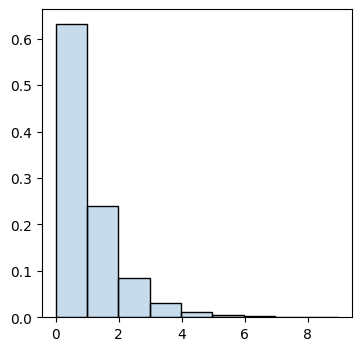

In [4]:
class ExponentialDecay(Distribution):
    def __init__(self):
        self._get_uvals()
        self._get_samples()

    def _get_uvals(self):
        self.uvals = np.random.rand(10000)

    def _get_samples(self):
        # the cdf is the integral of e^(-x) from 0 to x  -->  F(x) = 1-e(-x)
        # the inverse is then -ln(1-x)
        self.xvals = [-np.log(1-x) for x in self.uvals]
        self.xmin = min(self.xvals)
        self.xmax = max(self.xvals)


exponential = ExponentialDecay()

fig, axes = plt.subplots(1,1,figsize=(4,4))
exponential.plot(axes)
    


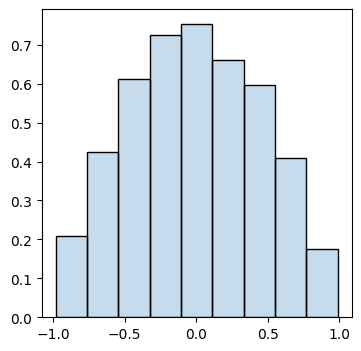

In [5]:
class ParabolicDensity(Distribution):
    def __init__(self):
        self._get_samples()

    def p(self, x):
        return 3/4 * (1-x**2)

    def _get_samples(self):
        self.xvals = []
        Nsamples = 10000
        Y = np.random.rand(Nsamples) * 3/4
        X = np.random.rand(Nsamples)*2 - 1    # -1 <= x <= 1
        # for i in range(Nsamples):
        #     y = 3/4 * U[i]
        #     x = X[i]
        #     if y < self.p(x):
        #         self.xvals.append((x,y))
        # return self.xvals
        accepted = Y < self.p(X)
        self.xvals = X[accepted]   #using masks
        self.xmin = min(self.xvals)
        self.xmax = max(self.xvals)
        return self.xvals

parabolic = ParabolicDensity()

fig, axes = plt.subplots(1,1,figsize=(4,4))

parabolic.plot(axes)
    

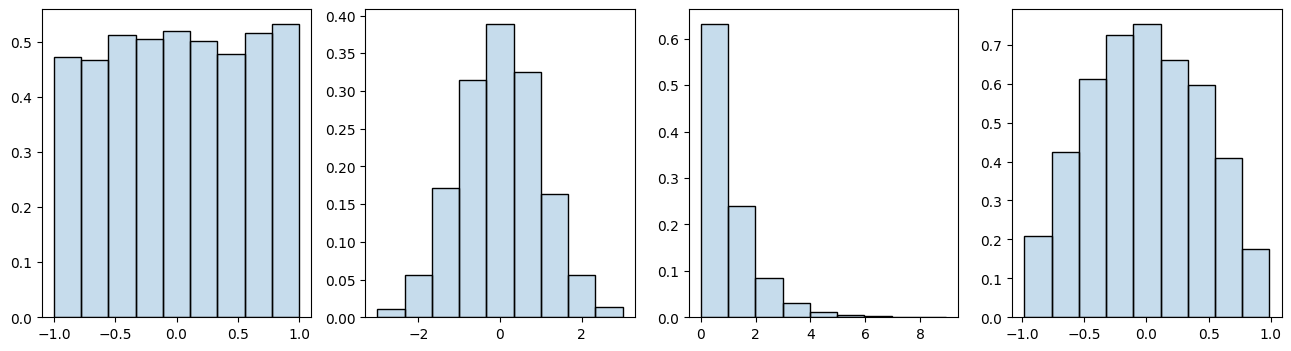

In [6]:
distributions = [uniform, normal, exponential, parabolic]
N = len(distributions)
fig , axes = plt.subplots (1, N, figsize = (4*N, 4))
for distribution, ax in zip(distributions, axes):
    distribution.plot(ax)

### W01B

d1=0.03931
d2=0.03956
d_circle=3.14928
N: 100, 2.96 +- 0.18159265358979315
N: 1000, 3.056 +- 0.08559265358979307
N: 10000, 3.1152 +- 0.026392653589792925
N: 100000, 3.13816 +- 0.0034326535897930555
N: 1000000, 3.140148 +- 0.0014446535897931767


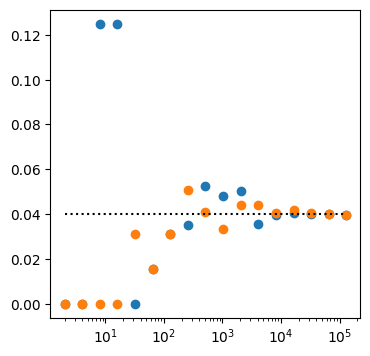

In [40]:
class MonteCarlo():
    def __init__(self, Nsamples = 100000, xmin=0, xmax=1, ymin=0, ymax=1):
        self.xmin = xmin
        self.xmax = xmax
        self.ymin = ymin
        self.ymax = ymax
        self.Nsamples = Nsamples

    def monte_carlo(self, boolean):
        sum = 0
        for (x,y) in self.samples:
            if boolean(x,y):
                sum += 1
        return sum / self.Nsamples

class UnitSquare(MonteCarlo):
    def __init__(self, Nsamples=100000):
        super().__init__(Nsamples)
        self._get_samples()

    def _get_samples(self):
        X = np.random.rand(self.Nsamples) * (self.xmax-self.xmin) + self.xmin
        Y = np.random.rand(self.Nsamples) * (self.ymax-self.ymin) + self.ymin
        self.samples = [(x,y) for x, y in zip(X, Y)]
        return self.samples
    
    def D1(self, x, y):
        return 0 < x < 0.2 and 0 < y < 0.2
    
    def D2(self, x, y):
        return 0.8 < x < 1 and 0 < y < 0.2

    def D_circle(self, x, y):
        return x**2 + y**2 < 1

        

indicator = UnitSquare()

d1 = indicator.monte_carlo(indicator.D1)
d2 = indicator.monte_carlo(indicator.D2)
d_circle = 4 * indicator.monte_carlo(indicator.D_circle)
print(f'{d1=}')
print(f'{d2=}')
print(f'{d_circle=}')

fig, axes = plt.subplots(1,1, figsize=(4,4))
d1_estimates = []
d2_estimates = []
N = []
for i in range(1, 18):
    n = 2**i
    N.append(n)
    unit_square = UnitSquare(n)
    d1_estimates.append(unit_square.monte_carlo(indicator.D1))
    d2_estimates.append(unit_square.monte_carlo(indicator.D2))
axes.scatter(N, d1_estimates)
axes.scatter(N, d2_estimates)
axes.hlines(0.2**2, N[0], N[-1], color='k', linestyle=':')
axes.set_xscale('log')


N = [100, 1000, 1e4, 1e5, 1e6]
for n in N:
    n = int(n)
    pi_estimator = UnitSquare(n)
    pi_estimate = 4 * pi_estimator.monte_carlo(pi_estimator.D_circle)
    pi = np.pi
    error = abs(pi_estimate-pi)
    print(f'N: {n}, {pi_estimate} +- {error}')

P1=0.08133333333333333
P2=0.034
P_circle=1.0
Area of square: 2.0


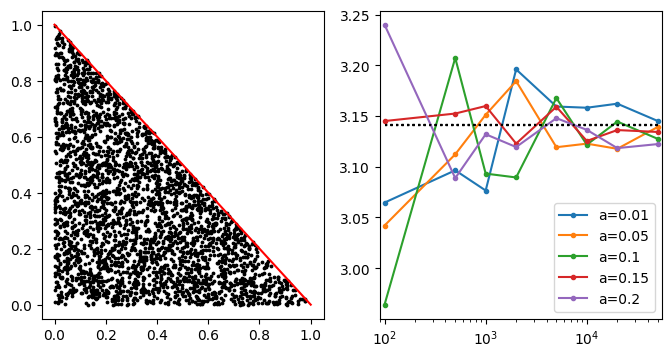

In [ ]:
class SkewedSquare(UnitSquare):
    def __init__(self, Nsamples=100, a=1, b=1):
        #self.Nsamples = Nsamples
        self.a = a
        self.b = b
        super().__init__(Nsamples)
        #self._get_samples()

    def _get_samples(self):
        samples = []
        b = self.b
        a = self.a
        for i in range(self.Nsamples):
            u = np.random.uniform(0, 1)
            x = (b - np.sqrt(b**2 - 2*a*(b-a/2)*u))/a
            v = np.random.uniform(0, 1)
            y = v * (b-a*x)
            samples.append((x,y))
        self.samples = samples
        return self.samples

    def plot(self, ax):
        x, y = zip(*self.samples)
        ax.scatter(x,y, color='k', s=3)
        ax.plot([0,1], [self.b, self.b-self.a], '-', color='red')

skewed = SkewedSquare(3000, 1, 1)

fig, axes = plt.subplots(1,2,figsize=(8,4))
skewed.plot(axes[0])
P1 = skewed.monte_carlo(skewed.D1)
P2 = skewed.monte_carlo(skewed.D2)
P_circle = skewed.monte_carlo(skewed.D_circle)
print(f'{P1=}')
print(f'{P2=}')
print(f'{P_circle=}')

# The quarter disk is not entirely contained in R(a,b)
# Instead, 4AP would estimate the area of a square with side length sqrt(2)
# This area should be sqrt(2)^2 = 2, so:
# In this case, A = 0.5, so.

print('Area of square:', 4 * 0.5 * P_circle)

probabilities = []
avals = [0.01, 0.05, 0.1, 0.15, 0.2]
Nsamples = [100, 500, 1000, 2000, 5000, 10000, 20000, 50000]
for a in avals:
    for N in Nsamples:
        efficiency = SkewedSquare(N, a, 1)
        area = 1 - a/2
        pi = 4*area*efficiency.monte_carlo(efficiency.D_circle)
        probabilities.append((N, pi))
x, y = zip(*probabilities)
for i, color, legend in zip(range(0,len(Nsamples)*len(avals),len(Nsamples)), ['C0', 'C1', 'C2', 'C3', 'C4'], avals):
    axes[1].plot(x[i:i+len(Nsamples)],y[i:i+len(Nsamples)], color=color, marker='o', ms=3, label=f'a={avals[i//len(Nsamples)]}')
    axes[1].hlines(np.pi, Nsamples[0], Nsamples[-1], color='k', ls=':')
    axes[1].set_xlim(Nsamples[0]-10, Nsamples[-1]+5000)
    axes[1].set_xscale('log')
plt.legend(loc='lower right')



### W01C

In [ ]:
class Node:
    def __init__(self, index):
        self.index = index
        self.neighbors = []

    def add_neighbor(self, other_node, transition_prob):
        self.neighbors.append((other_node, transition_prob))

transition_probs1 = [
(0, 0, 0.3),
(0, 1, 0.4),
(0, 2, 0.3),
(1, 0, 0.05),
(1, 1, 0.8875),
(1, 2, 0.0625),
(2, 0, 0.3),
(2, 1, 0.5),
(2, 2, 0.2)]

transition_probs2 = [
(0, 0, 0.5),
(0, 1, 0.2),
(0, 2, 0.3),
(1, 0, 0.025),
(1, 1, 0.9125),
(1, 2, 0.0625),
(2, 0, 0.3),
(2, 1, 0.5),
(2, 2, 0.2)]

class System:
    def __init__(self, nodes, n_trans=10):
        self.nodes = nodes
        self.matrix = self.transition_matrix()
        self.p = np.array([1.0,0.0,0.0])
        self.n_trans = n_trans
        self.run_p = self.run()

    def transition_matrix(self):
        matrix = np.zeros((3,3), dtype=float)
        for node in self.nodes:
            for neighbor, probability in node.neighbors:
                matrix[node.index, neighbor.index] = probability
        return matrix

    def run(self):
        for n in range(self.n_trans):
            self.p = self.p@self.matrix
        return self.p


for transition_probs in [transition_probs1, transition_probs2]:
    nodes = [Node(i) for i in range(3)]
    for i,j,t in transition_probs:
        nodes[i].add_neighbor(nodes[j],t)

    system = System(nodes=nodes, n_trans=100)
    print(system.matrix)
    print(system.run_p)
    # the limiting distribution is the same for P1 and P2
    # with just 10 iterations, we are fairly close to the same distribution



    # With the probability-vector calculations, the propagation is deterministic.
    # We would always arrive at the same conclusion, and see a distribution of
    # node 1 being the most likely state of 80%. Random initializations would
    # also always end up at the same distribution.
    # 
    # The stochastic propagation of one particular node of the system is random
    # and would not necessarily produce the same result each time. It would
    # return 0, 1, or 2, not a probability distribution. Different starting
    # points could yields different results. 


[[0.3    0.4    0.3   ]
 [0.05   0.8875 0.0625]
 [0.3    0.5    0.2   ]]
[0.1 0.8 0.1]
[[0.5    0.2    0.3   ]
 [0.025  0.9125 0.0625]
 [0.3    0.5    0.2   ]]
[0.1 0.8 0.1]
